# **Student Performance Indicator**
---

## Problem Statement
This project understands how the student's performance (test scores) is affected by other variables such as Gender, Race/Ethnicity, Parental level of education, Lunch and Test preparation course.



## About the Dataset

This analysis uses the **Students Performance in Exams Dataset** obtained from Kaggle.

**Dataset Source:**  
https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

The dataset contains information about **1000 students** and their performance in three academic subjects: **Mathematics, Reading, and Writing**. Along with the exam scores, the dataset includes several **demographic and socio-economic attributes** that may influence student academic outcomes.

The dataset consists of **1000 observations (rows)** and **8 features (columns)**.


### Dataset Features

| Column Name | Description |
|-------------|-------------|
| **gender** | Gender of the student |
| **race_ethnicity** | Categorical group representing the student's race or ethnicity |
| **parental_level_of_education** | Highest level of education attained by the student's parents |
| **lunch** | Type of lunch program received by the student (standard or free/reduced) |
| **test_preparation_course** | Indicates whether the student completed a test preparation course |
| **math_score** | Score obtained by the student in the Mathematics exam |
| **reading_score** | Score obtained by the student in the Reading exam |
| **writing_score** | Score obtained by the student in the Writing exam |

## Data Overview

In [330]:
import numpy as np  # Numerical computing and array operations
import pandas as pd  # Data manipulation and analysis (DataFrames)
import seaborn as sns  # Statistical data visualization
import matplotlib.pyplot as plt  # Plotting library for creating graphs
%matplotlib inline          
import warnings  # Module to handle warning messages
warnings.filterwarnings("ignore")  # Suppress warning messages for cleaner output

In [ ]:
df = pd.read_csv("data/stud.csv")  # reading dataset

In [ ]:

print("Shape of the dataset :", df.shape) # shape of the dataset

Shape of the dataset : (1000, 8)


In [ ]:
df.head(5) # first five rows

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.tail(5) # last five columns

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [ ]:
print("Columnns in the dataset :", df.columns.tolist()) # column names

Columnns in the dataset : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


In [ ]:
df.info()  # dataset info

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


The dataset contains 5 categorical variables and 3 numerical variables. There are no missing values present in the dataset.

In [331]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()  # Get categorical columns
numerical_columns = df.select_dtypes(include=["int"]).columns.tolist()       # Get numerical columns

print(f"There are {len(categorical_columns)} categorical features: {categorical_columns}\n")  # Print categorical features
print(f"There are {len(categorical_columns)} numerical features: {numerical_columns}")        # Print numerical features

There are 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']

There are 5 numerical features: ['math_score', 'reading_score', 'writing_score']


In [289]:
df.isnull().sum() # checking null values

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

No missing values were found in the dataset.

In [288]:
df.duplicated().sum() # duplicated rows

np.int64(0)

No duplicated rows were found in the dataset.

In [287]:
df.nunique() # number of unique data in each column.

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [332]:
# listing the unique datapoints in categorical column
for i in categorical_columns:
    print(f"Categories in {i} variable: {df[i].unique().tolist()}\n")

Categories in gender variable: ['Female', 'Male']

Categories in race_ethnicity variable: ['Group B', 'Group C', 'Group A', 'Group D', 'Group E']

Categories in parental_level_of_education variable: ['Undergraduate', 'Postgraduate', 'Intermediate']

Categories in lunch variable: ['Standard Lunch', 'Free/Reduced Lunch']

Categories in test_preparation_course variable: ['No Prep', 'Completed Course']



In [ ]:
df.describe() # descriptive statistics


,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


The mean and median are nearly equal, it suggests that the score distributions are approximately symmetric and not heavily skewed. This indicates that extreme outliers or strong skewness are unlikely to significantly affect the central tendency of the scores.

In [ ]:
df[["math_score", "reading_score", "writing_score"]].skew() #checking skewness of the numerical columns

math_score      -0.278935
reading_score   -0.259105
writing_score   -0.289444
dtype: float64

The skewness values for math, reading, and writing scores are all slightly negative.
- Negative skewness indicates that the left tail of the distribution is slightly longer, meaning a small number of students scored relatively lower compared to the majority.
- However, the skewness values are close to 0, which suggests that the distributions are approximately symmetric with only mild skewness.

## Data Cleaning

In [312]:
# Standardizing categorical values
df["parental_level_of_education"] = df["parental_level_of_education"].replace({"some college": "Undergraduate", "bachelor's degree" : "Undergraduate", "associate's degree": "Undergraduate", "master's degree" : "Postgraduate", "high school":"Intermediate", "some high school": "Intermediate"})

df["test_preparation_course"] = df["test_preparation_course"].replace({"none":"No Prep", "completed": "Completed Course"})

df['lunch'] = df['lunch'].replace({'free/reduced': 'Free/Reduced Lunch', 'standard': 'Standard Lunch'})

df["gender"] = df["gender"].replace({"female": "Female", "male":"Male"})

df["race_ethnicity"] = df["race_ethnicity"].replace({"group A":"Group A", "group B":"Group B", "group C":"Group C", "group D":"Group D", "group E":"Group E"})

## Feature Extraction

In [333]:
# creating an average of marks column
df['average'] = (df['math_score'] + df['reading_score'] + df['writing_score'])/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average
0,Female,Group B,Undergraduate,Standard Lunch,No Prep,72,72,74,72.666667
1,Female,Group C,Undergraduate,Standard Lunch,Completed Course,69,90,88,82.333333
2,Female,Group B,Postgraduate,Standard Lunch,No Prep,90,95,93,92.666667
3,Male,Group A,Undergraduate,Free/Reduced Lunch,No Prep,47,57,44,49.333333
4,Male,Group C,Undergraduate,Standard Lunch,No Prep,76,78,75,76.333333


A new feature average_score was created to represent the overall academic performance of each student across the three domains.

In [341]:
df[["gender", "race_ethnicity", "parental_level_of_education", "lunch", "test_preparation_course", "average" ]].to_csv("data\cleaned_data.csv")

## Univariate Analysis

In [334]:
reading_75 = df[df["reading_score"]>75]["average"].count()      # Students scoring >75 in reading
writing_75 = df[df["writing_score"]>75]["average"].count()      # Students scoring >75 in writing
math_full_75 = df[df["math_score"]>75]["average"].count()       # Students scoring >75 in maths

read = df[df["reading_score"]>75]["gender"].value_counts().tolist()   # Gender split for reading distinction
writ = df[df["writing_score"]>75]["gender"].value_counts().tolist()   # Gender split for writing distinction
math = df[df["math_score"]>75]["gender"].value_counts().tolist()      # Gender split for maths distinction


reading_fail = df[df["reading_score"]<33]["average"].count()    # Students failing reading (<33)
writing_fail = df[df["writing_score"]<33]["average"].count()    # Students failing writing (<33)
math_fail = df[df["math_score"]<33]["average"].count()          # Students failing maths (<33)

readf = df[df["reading_score"]<33]["gender"].value_counts().tolist()  # Gender split for reading failures
writf = df[df["writing_score"]<33]["gender"].value_counts().tolist()  # Gender split for writing failures
mathf = df[df["math_score"]<33]["gender"].value_counts().tolist()     # Gender split for maths failures

print(f'Number of students who achieved distinction in  Maths: {math_full_75}   Female: {math[0]}   Male: {math[1]}')
print(f'Number of students failed in Maths: {math_fail}   Female: {mathf[0]}   Male: {mathf[1]}\n')

print(f'Number of students who achieved distinction in  Writing: {writing_75}   Female: {writ[0]}   Male: {writ[1]}')
print(f'Number of students failed in Writing: {writing_fail}   Female: {writf[0]}   Male: {writf[1]}\n')

print(f'Number of students who achieved distinction in  Reading: {reading_75}   Female: {read[0]}   Male: {read[1]}')
print(f'Number of students failed in Reading: {reading_fail}   Female: {readf[0]}   Male: {readf[1]}')

Number of students who achieved distinction in  Maths: 274   Female: 162   Male: 112
Number of students failed in Maths: 19   Female: 15   Male: 4

Number of students who achieved distinction in  Writing: 328   Female: 231   Male: 97
Number of students failed in Writing: 12   Female: 7   Male: 5

Number of students who achieved distinction in  Reading: 344   Female: 225   Male: 119
Number of students failed in Reading: 11   Female: 6   Male: 5



Students perform best in Reading, followed by Writing and Maths. Female students achieve the most distinctions but also have a higher number of failures than males, while overall failure rates remain very low.

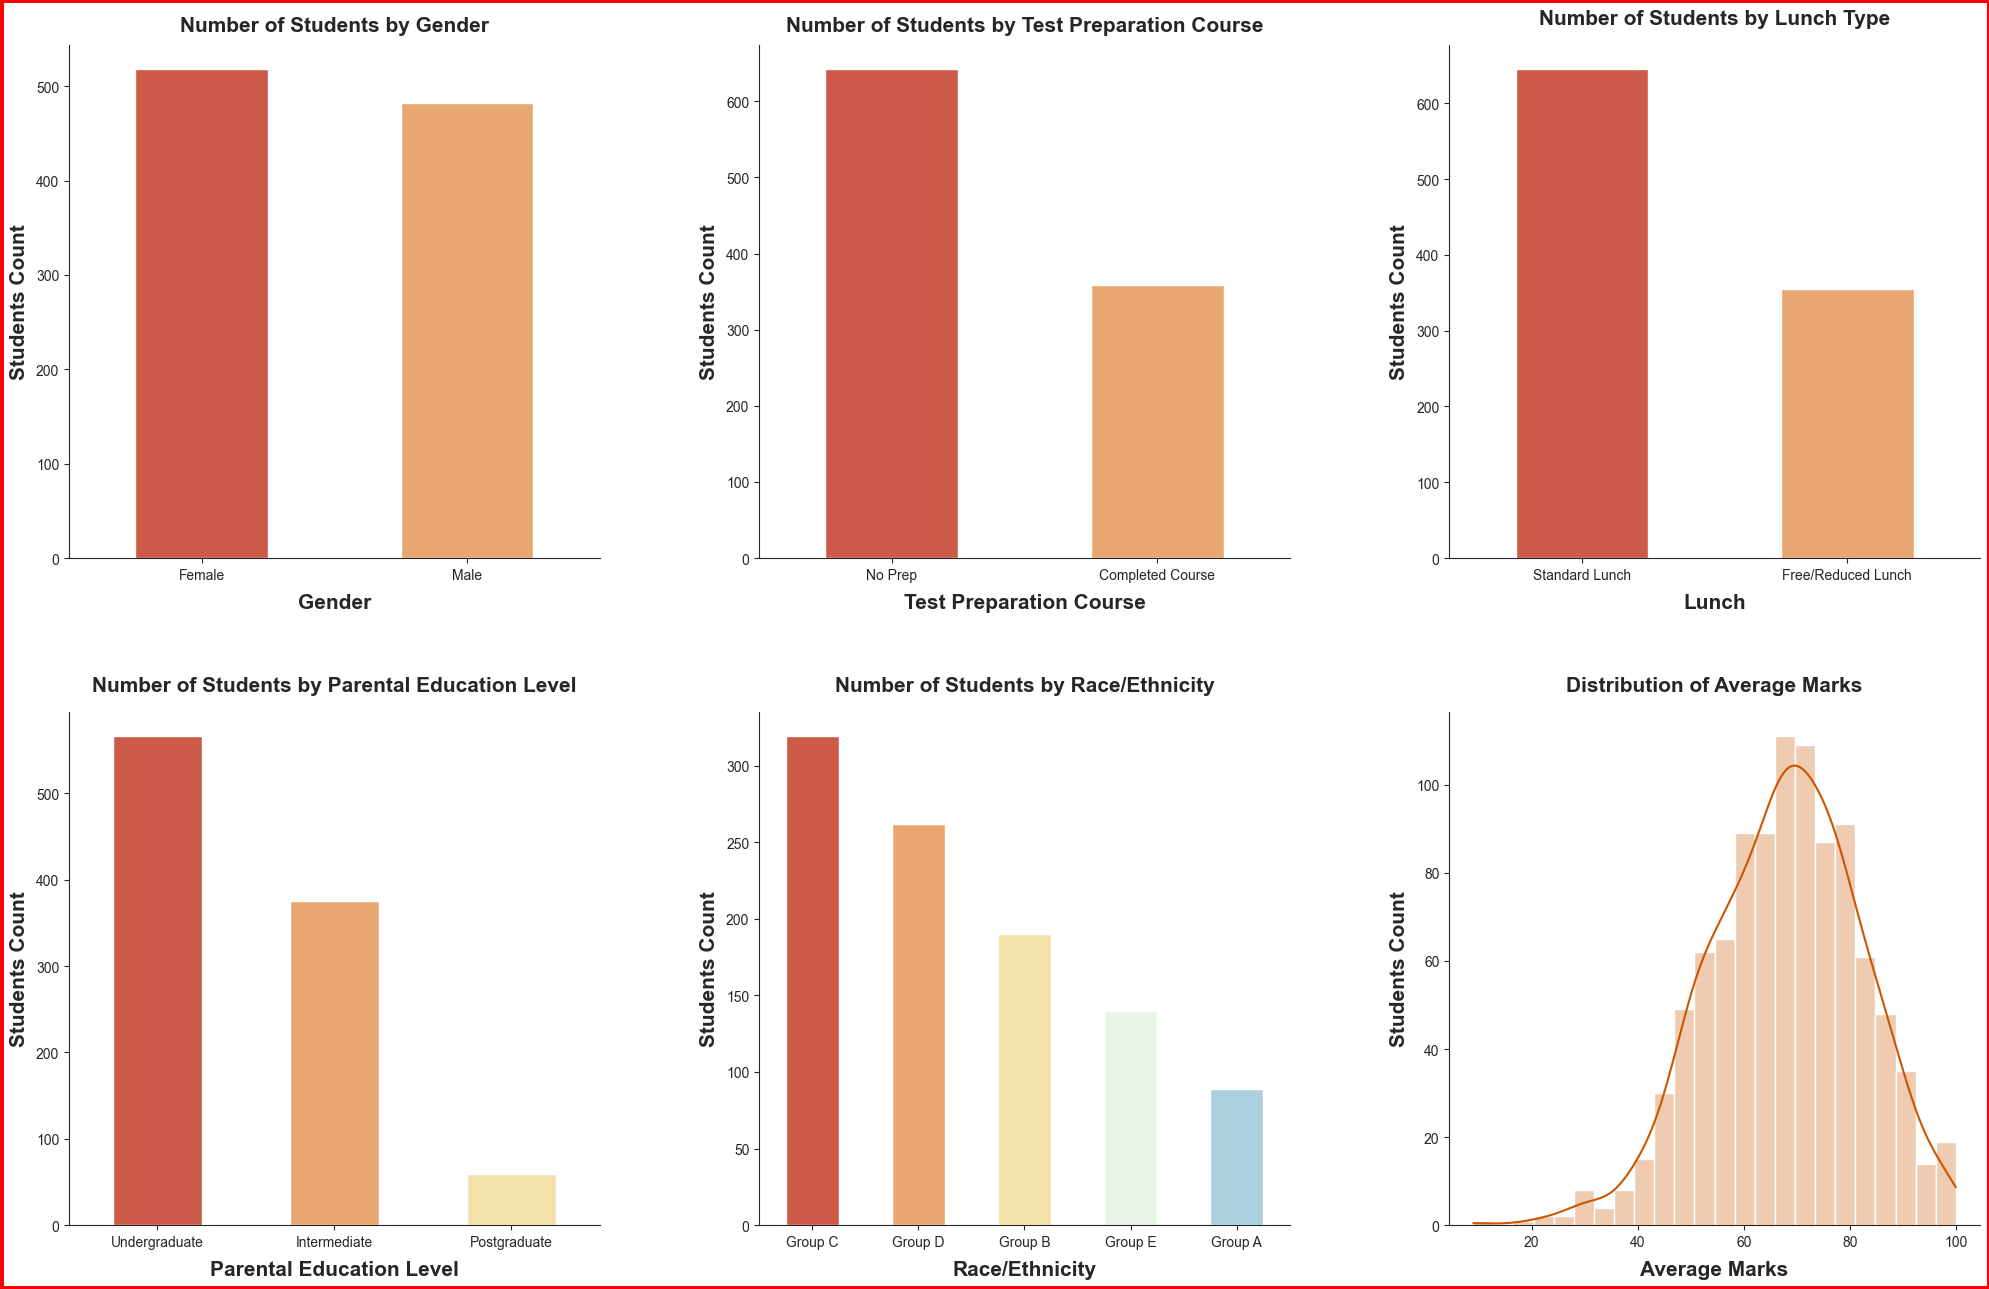

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(20,13))  # Create 2x3 subplot grid
fig.patch.set_edgecolor('red')  # Set figure border color
fig.patch.set_linewidth(5)  # Set figure border width
pall = sns.color_palette('RdYlBu')  # Define color palette

# Gender count plot
ax0 = sns.countplot(data=df, x="gender", width=0.5, 
                    order=df["gender"].value_counts().index, 
                    ax=axes[0,0], palette=pall)
ax0.set_title("Number of Students by Gender", fontweight="bold", fontsize=15, pad=10)
ax0.set_xlabel("Gender", fontsize=15, fontweight='bold', labelpad=8)
ax0.set_ylabel("Students Count", fontsize=15, fontweight='bold', labelpad=5)

# Test preparation course count plot
ax1 = sns.countplot(data=df, x="test_preparation_course", width=0.5, 
                    order=df["test_preparation_course"].value_counts().index, 
                    ax=axes[0,1], palette=pall)
ax1.set_title("Number of Students by Test Preparation Course", fontweight="bold", fontsize=15, pad=10)
ax1.set_xlabel("Test Preparation Course", fontsize=15, fontweight='bold', labelpad=8)
ax1.set_ylabel("Students Count", fontsize=15, fontweight='bold', labelpad=5)

# Lunch type count plot
ax2 = sns.countplot(data=df, x="lunch", width=0.5, 
                    order=df["lunch"].value_counts().index, 
                    ax=axes[0,2], palette=pall)
ax2.set_title("Number of Students by Lunch Type", fontweight="bold", fontsize=15, pad=15)
ax2.set_xlabel("Lunch", fontsize=15, fontweight='bold', labelpad=8)
ax2.set_ylabel("Students Count", fontsize=15, fontweight='bold', labelpad=5)

# Parental education level count plot
ax3 = sns.countplot(data=df, x="parental_level_of_education", width=0.5, 
                    order=df["parental_level_of_education"].value_counts().index, 
                    ax=axes[1,0], palette=pall)
ax3.set_title("Number of Students by Parental Education Level", fontweight="bold", fontsize=15, pad=15)
ax3.set_xlabel("Parental Education Level", fontsize=15, fontweight='bold', labelpad=8)
ax3.set_ylabel("Students Count", fontsize=15, fontweight='bold', labelpad=5)

# Race/Ethnicity count plot
ax4 = sns.countplot(data=df, x="race_ethnicity", width=0.5, 
                    order=df["race_ethnicity"].value_counts().index, 
                    ax=axes[1,1], palette=pall)
ax4.set_title("Number of Students by Race/Ethnicity", fontweight="bold", fontsize=15, pad=15)
ax4.set_xlabel("Race/Ethnicity", fontsize=15, fontweight='bold', labelpad=8)
ax4.set_ylabel("Students Count", fontsize=15, fontweight='bold', labelpad=5)

# Average marks distribution plot
ax5 = sns.histplot(data=df, x="average", ax=axes[1,2], kde=True, alpha=0.3, color="#cc5500")
ax5.set_title("Distribution of Average Marks", fontweight="bold", fontsize=15, pad=15)
ax5.set_xlabel("Average Marks", fontsize=15, fontweight='bold', labelpad=8)
ax5.set_ylabel("Students Count", fontsize=15, fontweight='bold', labelpad=5)

plt.tight_layout()  # Adjust subplot layout
plt.subplots_adjust(hspace=0.3, wspace=0.3)  # Set spacing between subplots
sns.despine()  # Remove top and right spines



1. Female students slightly outnumber male students in the dataset.  

2. Almost half the students have not completed the test preparation course, indicating a majority without prep.  

3. The number of students who receive Standard Lunch is almost twice the number of students who receive Free/Reduced Lunch.  

4. Most students have parents with Undergraduate education, followed by Intermediate, and very few with Postgraduate education.  

5. The largest groups are Group C and Group D, while Group A has the fewest students.  

6. Scores are approximately normally distributed, centered around the mid-60s to 70s, indicating most students score moderately high.

## Bivariate Analysis

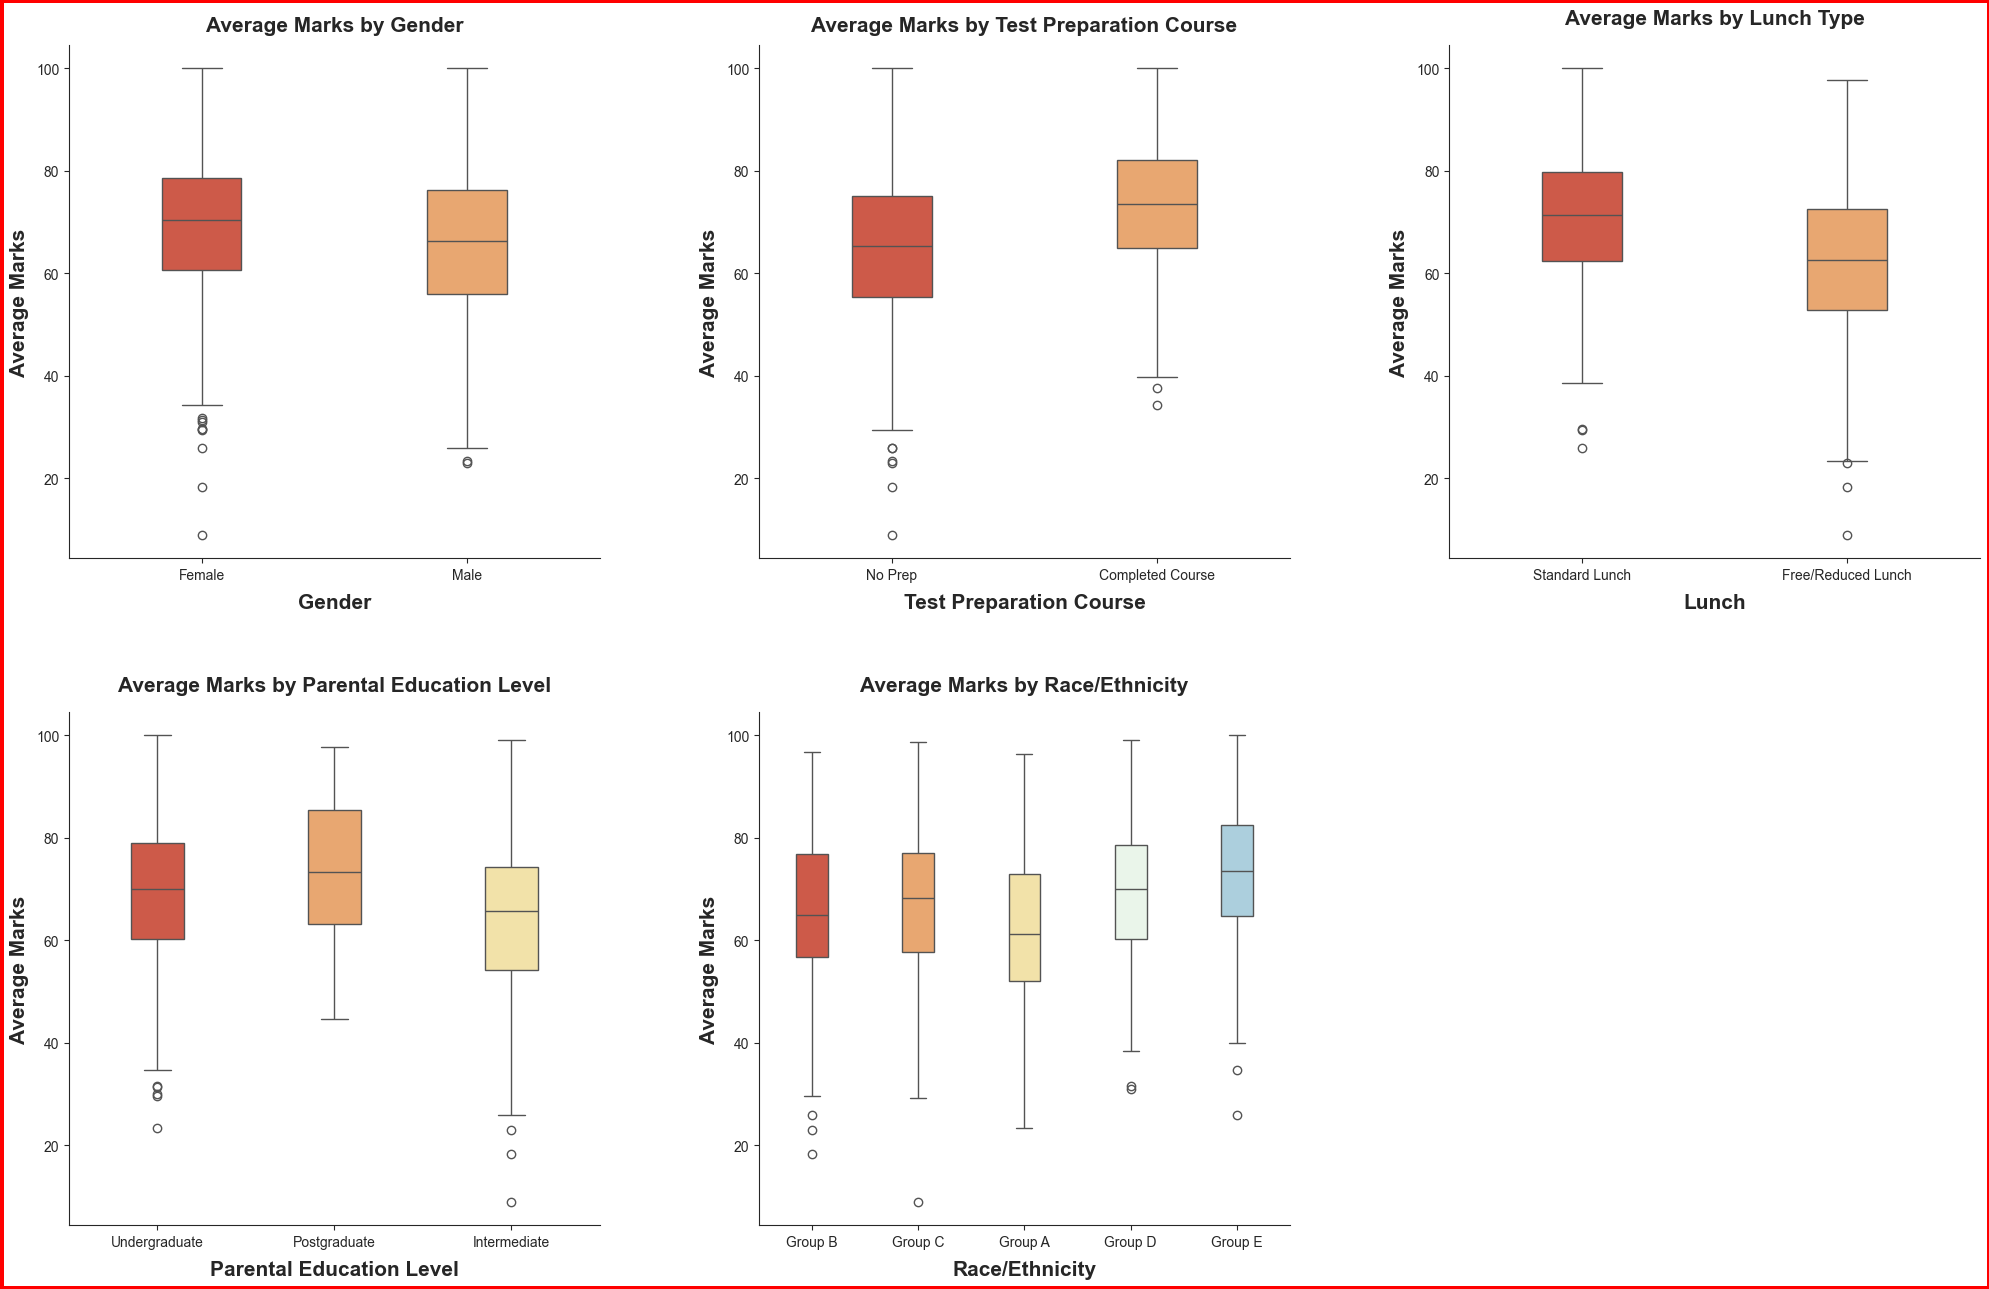

In [336]:
fig, axes = plt.subplots(2,3, figsize=(20,13))  # Create 2x3 subplot grid
fig.patch.set_edgecolor('red')  # Set figure border color
fig.patch.set_linewidth(5)  # Set figure border width
pall = sns.color_palette('RdYlBu')  # Define color palette

# Boxplot of average marks by gender
ax0 = sns.boxplot(data=df, x="gender", y="average", width=0.3, ax=axes[0,0], palette=pall)
ax0.set_title("Average Marks by Gender", fontweight="bold", fontsize=15, pad=10)
ax0.set_xlabel("Gender", fontsize=15, fontweight='bold', labelpad=8)
ax0.set_ylabel("Average Marks", fontsize=15, fontweight='bold', labelpad=5)

# Boxplot of average marks by test preparation course
ax1 = sns.boxplot(data=df, x="test_preparation_course", y="average", width=0.3, ax=axes[0,1], palette=pall)
ax1.set_title("Average Marks by Test Preparation Course", fontweight="bold", fontsize=15, pad=10)
ax1.set_xlabel("Test Preparation Course", fontsize=15, fontweight='bold', labelpad=8)
ax1.set_ylabel("Average Marks", fontsize=15, fontweight='bold', labelpad=5)

# Boxplot of average marks by lunch type
ax2 = sns.boxplot(data=df, x="lunch", y="average", width=0.3, ax=axes[0,2], palette=pall)
ax2.set_title("Average Marks by Lunch Type", fontweight="bold", fontsize=15, pad=15)
ax2.set_xlabel("Lunch", fontsize=15, fontweight='bold', labelpad=8)
ax2.set_ylabel("Average Marks", fontsize=15, fontweight='bold', labelpad=5)

# Boxplot of average marks by parental education level
ax3 = sns.boxplot(data=df, x="parental_level_of_education", y="average", width=0.3, ax=axes[1,0], palette=pall)
ax3.set_title("Average Marks by Parental Education Level", fontweight="bold", fontsize=15, pad=15)
ax3.set_xlabel("Parental Education Level", fontsize=15, fontweight='bold', labelpad=8)
ax3.set_ylabel("Average Marks", fontsize=15, fontweight='bold', labelpad=5)

# Boxplot of average marks by race/ethnicity
ax4 = sns.boxplot(data=df, x="race_ethnicity", y="average", width=0.3, ax=axes[1,1], palette=pall)
ax4.set_title("Average Marks by Race/Ethnicity", fontweight="bold", fontsize=15, pad=15)
ax4.set_xlabel("Race/Ethnicity", fontsize=15, fontweight='bold', labelpad=8)
ax4.set_ylabel("Average Marks", fontsize=15, fontweight='bold', labelpad=5)

# Hide unused subplot
axes[1,2].set_visible(False)

plt.tight_layout()  # Adjust subplot layout
plt.subplots_adjust(hspace=0.3, wspace=0.3) # Set spacing between subplots
sns.despine()  # Remove top and right spines


1. Female students have a slightly higher median average score than males, though the overall distribution of marks is similar for both genders.

2. Students who completed the test preparation course have noticeably higher median scores and fewer low-score outliers compared to those who did not take the course.

3. Students with standard lunch tend to achieve higher average marks, while those with free/reduced lunch show lower median scores and more variability.

4. Students whose parents have postgraduate education show the highest median scores, followed by undergraduate, while intermediate education corresponds to comparatively lower performance.

5. Average marks vary across groups, with Group E and Group D showing higher median scores, while Group A tends to have comparatively lower median performance.

## Multivariate Analysis

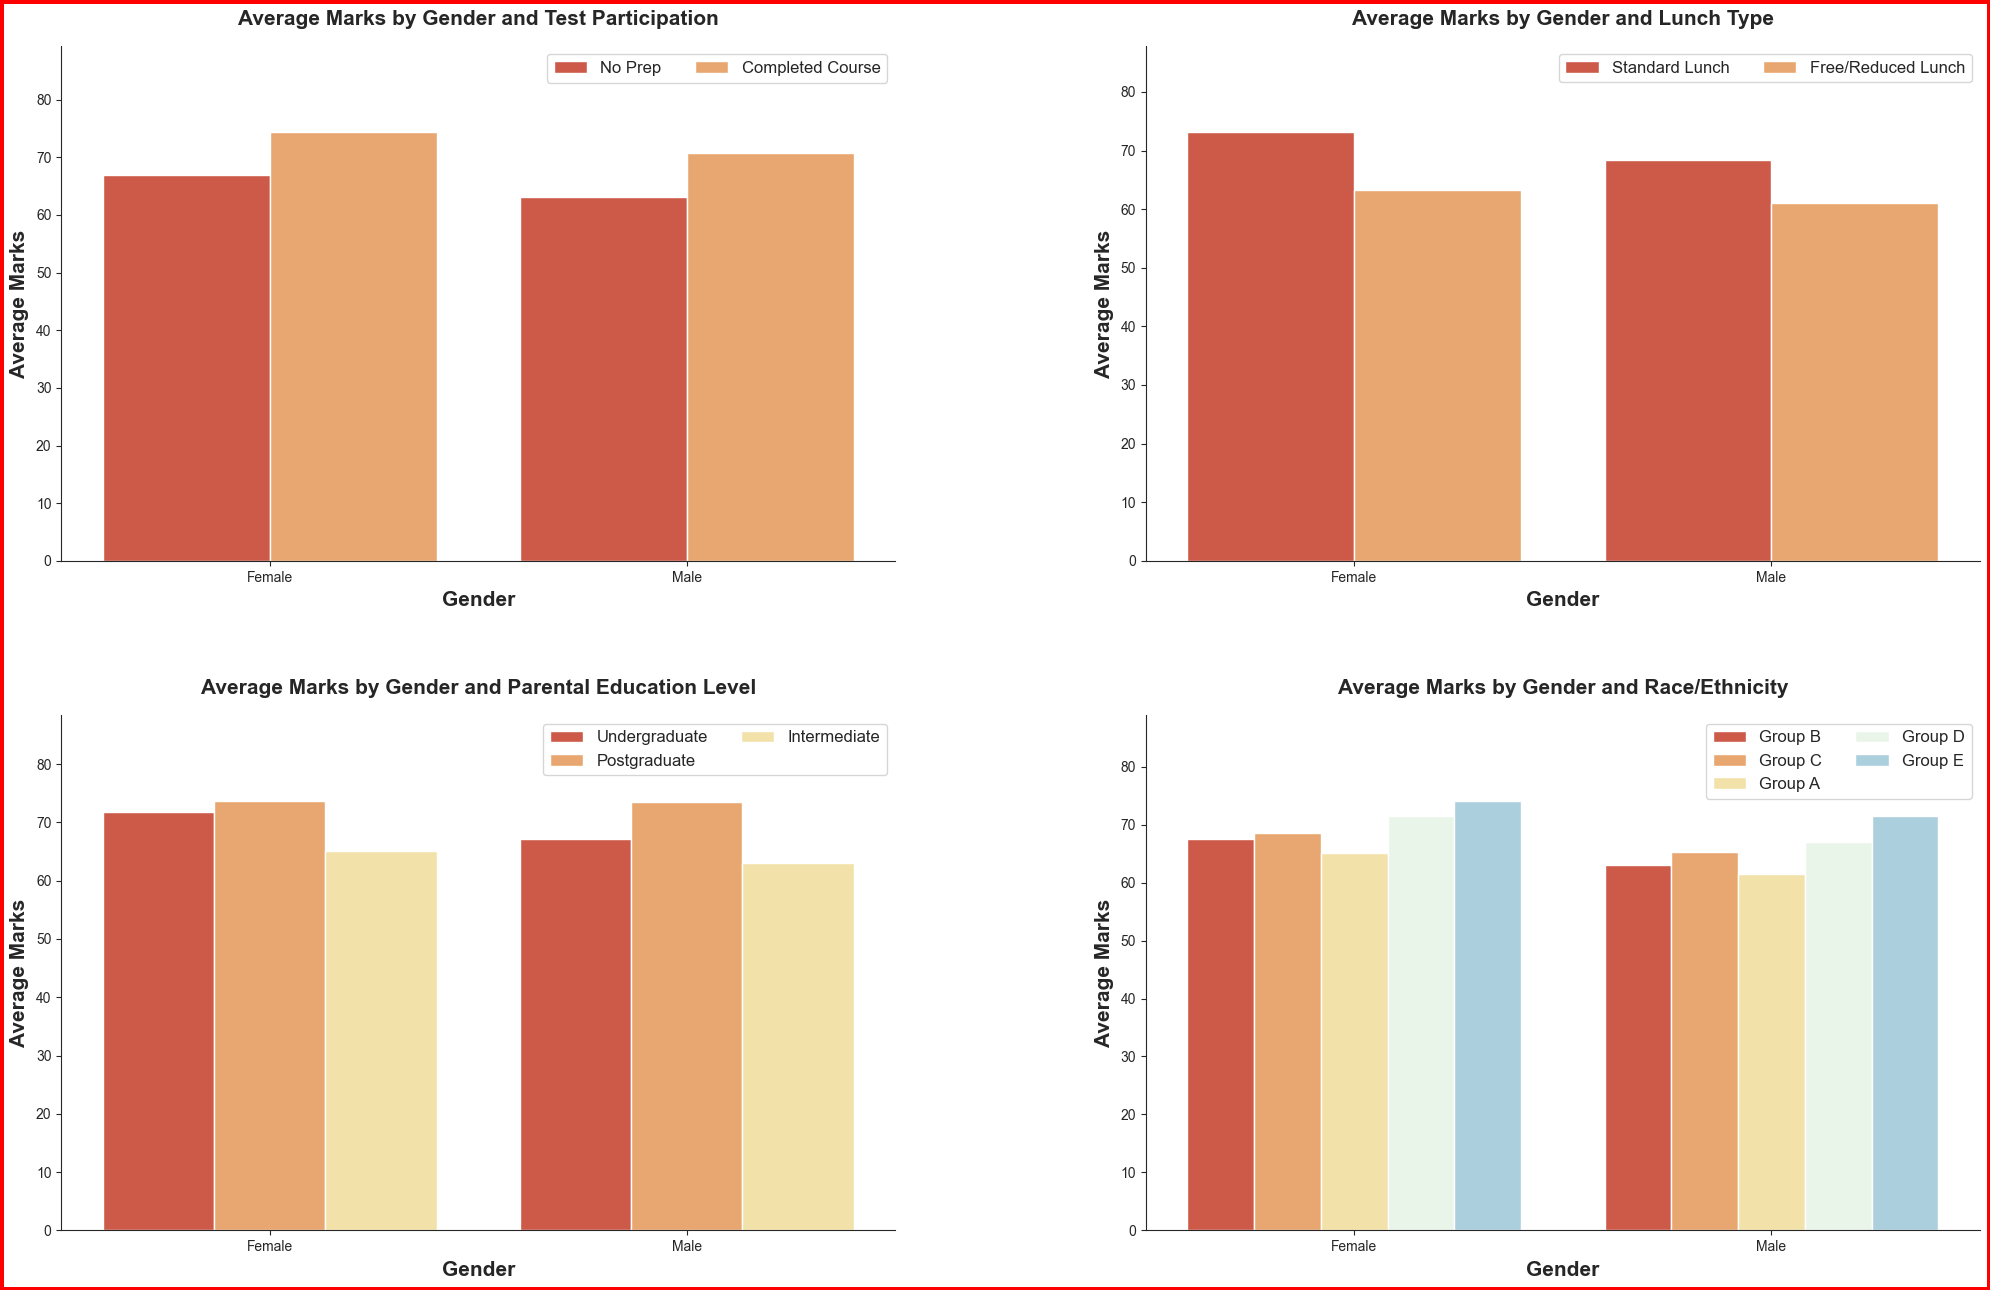

In [337]:

fig, axes = plt.subplots(2,2, figsize=(20,13))  # Create 2x2 subplot grid
fig.patch.set_edgecolor('red')  # Set figure border color
fig.patch.set_linewidth(5)   # Set figure border width
pall = sns.color_palette('RdYlBu')  # Define color palette

# Barplot: Average marks by gender and test preparation course
ax1 = sns.barplot(data=df, x="gender", y="average", hue="test_preparation_course", 
                  errorbar=None, legend="full", ax=axes[0,0], palette=pall)
ax1.set_title("Average Marks by Gender and Test Participation", fontweight="bold", fontsize=15, pad=15)

# Barplot: Average marks by gender and lunch type
ax2 = sns.barplot(data=df, x="gender", y="average", hue="lunch", 
                  errorbar=None, ax=axes[0,1], palette=pall)
ax2.set_title("Average Marks by Gender and Lunch Type", fontweight="bold", fontsize=15, pad=15)

# Barplot: Average marks by gender and parental education level
ax3 = sns.barplot(data=df, x="gender", y="average", hue="parental_level_of_education", 
                  errorbar=None, ax=axes[1,0], palette=pall)
ax3.set_title("Average Marks by Gender and Parental Education Level", fontweight="bold", fontsize=15, pad=15)

# Barplot: Average marks by gender and race/ethnicity
ax4 = sns.barplot(data=df, x="gender", y="average", hue="race_ethnicity", 
                  errorbar=None, ax=axes[1,1], palette=pall)
ax4.set_title("Average Marks by Gender and Race/Ethnicity", fontweight="bold", fontsize=15, pad=15)

# Common formatting for all subplots
for ax in axes.flatten():
    ax.margins(y=0.2)  # Add vertical margin
    ax.legend(fontsize=12, loc='upper right', markerscale=2, ncol=2, frameon=True)  # Customize legend
    ax.set_xlabel("Gender", fontsize=15, fontweight='bold', labelpad=5)
    ax.set_ylabel("Average Marks", fontsize=15, fontweight='bold', labelpad=5)

plt.tight_layout()  # Adjust subplot layout
plt.subplots_adjust(hspace=0.3, wspace=0.3)  # Set spacing between subplots
sns.despine()  # Remove top and right spines


1. Students who completed the test preparation course score higher on average for both genders, with females slightly outperforming males in both preparation categories.

2. Students with standard lunch have higher average marks than those with free/reduced lunch for both genders, indicating a possible link between socioeconomic status and performance.

3. Students whose parents have postgraduate education achieve the highest average scores for both genders, while intermediate parental education corresponds to the lowest performance.

4. Across both genders, average marks tend to increase from Group A/B toward Group D/E, with Group E showing the highest performance and females slightly outperforming males within most groups.

## Conclusion

- Female students generally achieve slightly higher average scores than males across most categories; however, they also account for a higher number of failures in the dataset.
- Test preparation plays a significant role in academic performance, as students who completed the preparation course consistently score higher than those who did not.
- Students receiving standard lunch have higher average marks compared to those receiving free or reduced lunch, indicating a possible association between lunch type and academic performance.
- Parental education level shows a clear relationship with student performance, where students whose parents have postgraduate education achieve higher scores, while those with intermediate parental education tend to score lower.
- Performance varies across race/ethnicity groups, with Group E and Group D generally showing higher average scores, while Group A tends to have comparatively lower performance.
- Among the subjects, students perform best in Reading, followed by Writing and Maths, indicating stronger language-related performance compared to mathematical performance.
- Overall score distributions are moderately high and approximately normal, suggesting that most students achieve average to above-average marks with relatively few failures.

---